# XG Boost Model

### Import Libraries

In [ ]:
!pip install --upgrade xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.9/253.9 MB 6.2 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 2.1.4
    Uninstalling xgboost-2.1.4:
      Successfully uninstalled xgboost-2.1.4


In [ ]:
import xgboost
print(xgboost.__version__)


3.0.0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
#from xgboost import EarlyStopping
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, r2_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ignore warnings (libraries are rapidly changing)
import warnings
warnings.filterwarnings('ignore')

### Read Data

In [ ]:
sarah_running = False  # Change to False when running in Colab

if sarah_running:
    X_train = pd.read_csv("/Users/sarahfarooq/Desktop/Master's/DATASCI 207/X_train.csv")
    X_test = pd.read_csv("/Users/sarahfarooq/Desktop/Master's/DATASCI 207/X_test.csv")
    X_val = pd.read_csv("/Users/sarahfarooq/Desktop/Master's/DATASCI 207/X_val.csv")
    y_train = pd.read_csv("/Users/sarahfarooq/Desktop/Master's/DATASCI 207/y_train.csv")
    y_test = pd.read_csv("/Users/sarahfarooq/Desktop/Master's/DATASCI 207/y_test.csv")
    y_val = pd.read_csv("/Users/sarahfarooq/Desktop/Master's/DATASCI 207/y_val.csv")

else:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = '/content/drive/My Drive/207 Final Project_407_214pm'

    X_train = pd.read_csv(f"{base_path}/X_train.csv")
    X_test = pd.read_csv(f"{base_path}/X_test.csv")
    X_val = pd.read_csv(f"{base_path}/X_val.csv")
    y_train = pd.read_csv(f"{base_path}/y_train.csv")
    y_test = pd.read_csv(f"{base_path}/y_test.csv")
    y_val = pd.read_csv(f"{base_path}/y_val.csv")


Mounted at /content/drive


In [ ]:
# # print shapes
print('Shape of X_train images ', X_train.shape)
print('Shape of y_train labels ', y_train.shape)

print('Shape of X_val images ', X_val.shape)
print('Shape of y_val labels ', y_val.shape)

print('Shape of X_test images ', X_test.shape)
print('Shape of y_test labels ', y_test.shape)

Shape of X_train images  (12426, 345)
Shape of y_train labels  (12426, 3)
Shape of X_val images  (4142, 345)
Shape of y_val labels  (4142, 3)
Shape of X_test images  (4142, 345)
Shape of y_test labels  (4142, 3)


### Split y data into 3, 7, and 14 days

In [ ]:
# For y_3
y_train_3 = y_train[['y_3']]
y_test_3 = y_test[['y_3']]
y_val_3 = y_val[['y_3']]

# For y_7
y_train_7 = y_train[['y_7']]
y_test_7 = y_test[['y_7']]
y_val_7 = y_val[['y_7']]

# For y_14
y_train_14 = y_train[['y_14']]
y_test_14 = y_test[['y_14']]
y_val_14 = y_val[['y_14']]

### Split X data into 3, 7, and 14 days

In [ ]:
# X_train_3, X_test_3, X_val_3
# Filter out columns that end with 'LAG_7' or 'LAG_14'
columns_to_keep_3 = [col for col in X_train.columns if not (col.endswith('LAG_7') or col.endswith('LAG_14'))]

# Create the new dataframes
X_train_3 = X_train[columns_to_keep_3]
X_test_3 = X_test[columns_to_keep_3]
X_val_3 = X_val[columns_to_keep_3]

# X_train_7, X_test_7, X_val_7
# Filter out columns that end with 'LAG_3' or 'LAG_14'
columns_to_keep_7 = [col for col in X_train.columns if not (col.endswith('LAG_3') or col.endswith('LAG_14'))]

# Create the new dataframes
X_train_7 = X_train[columns_to_keep_7]
X_test_7 = X_test[columns_to_keep_7]
X_val_7 = X_val[columns_to_keep_7]

# X_train_14, X_test_14, X_val_14
# Filter out columns that end with 'LAG_3' or 'LAG_7'
columns_to_keep_14 = [col for col in X_train.columns if not (col.endswith('LAG_3') or col.endswith('LAG_7'))]

# Create the new dataframes
X_train_14 = X_train[columns_to_keep_14]
X_test_14 = X_test[columns_to_keep_14]
X_val_14 = X_val[columns_to_keep_14]

### Encode any columns that have dtype 'object'

In [ ]:
def encode_object_columns(df):
    df_encoded = df.copy()
    for col in df_encoded.columns:
        if df_encoded[col].dtype == 'object':
            df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))
    return df_encoded

# 3-day data
X_train_3 = encode_object_columns(X_train_3)
X_val_3 = encode_object_columns(X_val_3)
X_test_3 = encode_object_columns(X_test_3)

# 7-day data
X_train_7 = encode_object_columns(X_train_7)
X_val_7 = encode_object_columns(X_val_7)
X_test_7 = encode_object_columns(X_test_7)

# 14-day data
X_train_14 = encode_object_columns(X_train_14)
X_val_14 = encode_object_columns(X_val_14)
X_test_14 = encode_object_columns(X_test_14)

In [ ]:
# # print shapes
print('Shape of X_train images ', X_train_3.shape)
print('Shape of y_train labels ', y_train_3.shape)

print('Shape of X_val images ', X_val_3.shape)
print('Shape of y_val labels ', y_val_3.shape)

print('Shape of X_test images ', X_test_3.shape)
print('Shape of y_test labels ', y_test_3.shape)

Shape of X_train images  (12426, 191)
Shape of y_train labels  (12426, 1)
Shape of X_val images  (4142, 191)
Shape of y_val labels  (4142, 1)
Shape of X_test images  (4142, 191)
Shape of y_test labels  (4142, 1)


### Define XG Boost model function

In [ ]:
def run_xgboost_model(X_train, y_train, X_val, y_val, X_test, y_test,
                      n_estimators, max_depth, learning_rate, label_days):
    # Initialize XGBoost classifier
    xgb = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )

    # Train model
    xgb.fit(X_train, y_train)

    # Predict on training and validation data
    y_train_pred = xgb.predict(X_train)
    y_val_pred = xgb.predict(X_val)
    y_test_pred = xgb.predict(X_test)


    print(y_train.shape, y_train_pred.shape)

    # Accuracy
    print(f"\n XGBoost Model for Fire in {label_days} Days")
    print("Training Accuracy:", round(accuracy_score(y_train, y_train_pred) * 100, 2), "%")
    print("Validation Accuracy:", round(accuracy_score(y_val, y_val_pred) * 100, 2), "%")
    print("Test Accuracy:", round(accuracy_score(y_test, y_test_pred) * 100, 2), "%")

    ## Additional metrics per dataset
    for label, y_true, y_pred in [
        ("Training", y_train, y_train_pred),
        ("Validation", y_val, y_val_pred),
        ("Test", y_test, y_test_pred)
    ]:
        print(f"\n {label} Metrics:")
        print("Precision :", round(precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2), "%")
        print("Recall    :", round(recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2), "%")
        print("F1 Score  :", round(f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2), "%")
        print("R² Score  :", round(r2_score(y_true, y_pred), 4))

    # Confusion matrix for validation set
    cm = confusion_matrix(y_val, y_val_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix (Validation) - Fire in {label_days} Days")
    plt.show()


### Run XG Boost to predict fires in 3 days

(12426, 1) (12426,)

 XGBoost Model for Fire in 3 Days
Training Accuracy: 71.54 %
Validation Accuracy: 56.78 %
Test Accuracy: 53.02 %

 Training Metrics:
Precision : 70.43 %
Recall    : 71.54 %
F1 Score  : 70.25 %
R² Score  : 0.3912

 Validation Metrics:
Precision : 54.76 %
Recall    : 56.78 %
F1 Score  : 54.59 %
R² Score  : 0.1235

 Test Metrics:
Precision : 50.55 %
Recall    : 53.02 %
F1 Score  : 50.79 %
R² Score  : 0.0075


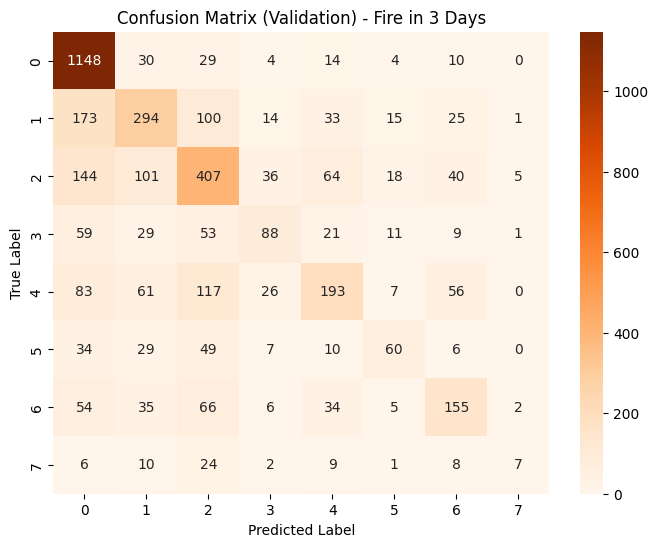

In [ ]:
# Fire in 3 days
run_xgboost_model(X_train_3, y_train_3, X_val_3, y_val_3, X_test_3, y_test_3,
                  n_estimators=100, max_depth=4, learning_rate=0.1, label_days=3)

### Run XG Boost to predict fires in 7 days

(12426, 1) (12426,)

 XGBoost Model for Fire in 7 Days
Training Accuracy: 69.51 %
Validation Accuracy: 39.5 %
Test Accuracy: 40.68 %

 Training Metrics:
Precision : 71.48 %
Recall    : 69.51 %
F1 Score  : 68.84 %
R² Score  : 0.4042

 Validation Metrics:
Precision : 38.23 %
Recall    : 39.5 %
F1 Score  : 34.77 %
R² Score  : -0.1858

 Test Metrics:
Precision : 39.35 %
Recall    : 40.68 %
F1 Score  : 36.75 %
R² Score  : -0.2103


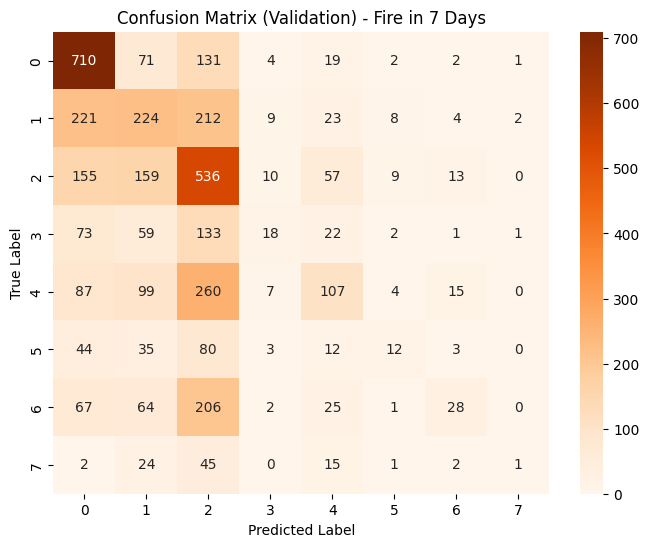

In [ ]:
# Fire in 7 days
run_xgboost_model(X_train_7, y_train_7, X_val_7, y_val_7, X_test_7, y_test_7,
                  n_estimators=150, max_depth=5, learning_rate=0.05, label_days=7,)

### Run XG Boost to predict fires in 14 days

(12426, 1) (12426,)

 XGBoost Model for Fire in 14 Days
Training Accuracy: 76.77 %
Validation Accuracy: 31.24 %
Test Accuracy: 33.63 %

 Training Metrics:
Precision : 78.54 %
Recall    : 76.77 %
F1 Score  : 76.73 %
R² Score  : 0.5279

 Validation Metrics:
Precision : 25.66 %
Recall    : 31.24 %
F1 Score  : 25.88 %
R² Score  : -0.3925

 Test Metrics:
Precision : 29.15 %
Recall    : 33.63 %
F1 Score  : 28.44 %
R² Score  : -0.26


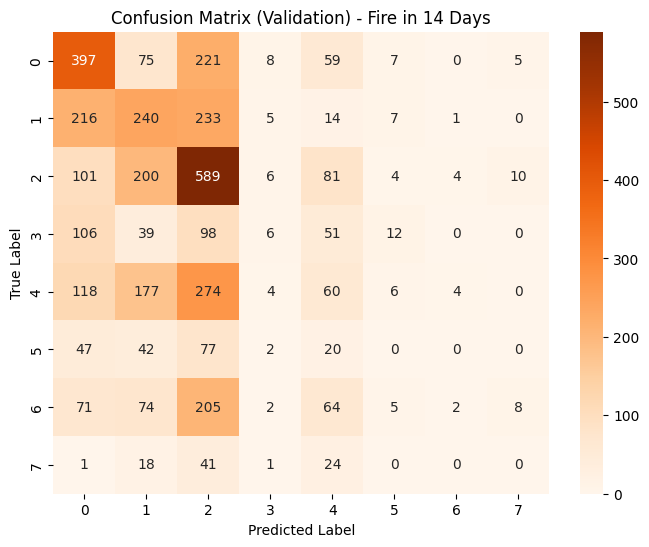

In [ ]:
# Fire in 14 days
run_xgboost_model(X_train_14, y_train_14, X_val_14, y_val_14, X_test_14, y_test_14,
                  n_estimators=200, max_depth=6, learning_rate=0.03, label_days=14)

###Hyperparameter tuning (predict fires in 3 days)

In [ ]:
#distribution of target labels in y_train_3
print(y_train_3.value_counts())

y_3
0      5196
2      2133
1      1982
4      1108
6       890
3       566
5       337
7       214
Name: count, dtype: int64


# As seen in the confusion matrix and the previous cell, the data is heavily unbalanced, with a bias toward Class O.   Next step, attempt to balance the classes by weighting the classes based on frequency.

# Rebalancing using Weighting

In [ ]:
#Add weights so the model pays more attention to minority classes (rebalance)


# flatten target labels
y_train_3_flat = y_train_3.values.ravel() #use ravel instead of flatten - makes a copy so less efficient
y_val_3_flat = y_val_3.values.ravel()
y_test_3_flat = y_test_3.values.ravel()


#get labels (unique)
labels = np.unique(y_train_3_flat)


#calc class weights using sklearn.utils.class_weight
weights = compute_class_weight(class_weight='balanced', classes=labels, y=y_train_3_flat)
class_weights = dict(zip(labels, weights))
class_weights

{np.int64(0): np.float64(0.29893187066974597),
 np.int64(1): np.float64(0.783678102926337),
 np.int64(2): np.float64(0.7281997187060478),
 np.int64(3): np.float64(2.7442579505300353),
 np.int64(4): np.float64(1.401850180505415),
 np.int64(5): np.float64(4.609050445103858),
 np.int64(6): np.float64(1.7452247191011236),
 np.int64(7): np.float64(7.258177570093458)}

In [ ]:
#Mapping of class labels to their correspoding weights from the dict
sample_weight = np.array([class_weights[label] for label in y_train_3_flat])
#sample_weight = y_train_3.map(class_weights)

In [ ]:
# Initialize XGBoost model for weighted classes

n_estimators = 100 #num of trees to build
max_depth = 4 # max tree depth
learning_rate = 0.1 # step size to prevent ovrfitting

In [ ]:
#Format for XGBoost Earlystopping from documentation
# es = xgboost.callback.EarlyStopping(
#     rounds=2,
#     min_delta=1e-3,
#     save_best=True,
#     maximize=False,
#     data_name="validation_0",
#     metric_name="mlogloss",
# )
# clf = xgboost.XGBClassifier(tree_method="hist", device="cuda", callbacks=[es])

# X, y = load_digits(return_X_y=True)
# clf.fit(X, y, eval_set=[(X, y)])

In [ ]:
def evaluate_model(xgb, X_train, y_train, X_val, y_val, X_test, y_test, label_days=3):

    y_train_pred = xgb.predict(X_train) #make predictions on training to evaluate how well model learned on training
    y_val_pred = xgb.predict(X_val) # make predictions on val to evaluate how well model generalizes during training
    y_test_pred = xgb.predict(X_test)

# Accuracy

    print(f"XGBoost Model for Fire in {label_days} Days")
    print("Training Accuracy:", round(accuracy_score(y_train, y_train_pred) * 100, 2), "%")
    print("Validation Accuracy:", round(accuracy_score(y_val, y_val_pred) * 100, 2), "%")
    print("Test Accuracy:", round(accuracy_score(y_test, y_test_pred) * 100, 2), "%")

    ## Additional metrics per dataset
    for label, y_true, y_pred in [
        ("Training", y_train, y_train_pred),
        ("Validation", y_val, y_val_pred),
        ("Test", y_test, y_test_pred)
        ]:

        print(f"\n {label} Metrics:")
        print("Precision :", round(precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2), "%")
        print("Recall    :", round(recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2), "%")
        print("F1 Score  :", round(f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2), "%")
        print("R² Score  :", round(r2_score(y_true, y_pred), 4))


    # Confusion matrix for validation set
    cm = confusion_matrix(y_val, y_val_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix (Validation) - Fire in {label_days} Days")
    plt.show()

    return()

#function to fit model with weighted classes with early stop
def run_xgboost_model_class_weights(X_train, y_train, X_val, y_val, X_test, y_test,
                    label_days, sample_weight=None, n_estimators=100, max_depth=4, learning_rate=0.1):

    xgb = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        use_label_encoder=False,
        eval_metric='mlogloss',
        early_stopping_rounds=20,
        random_state=42
        )

    #fit model with sample wts
    xgb.fit(X_train, y_train, sample_weight=sample_weight,
             eval_set=[(X_val, y_val)],
             verbose=False)

     # Predict on training and validation data
    y_train_pred = xgb.predict(X_train)
    y_val_pred = xgb.predict(X_val)
    y_test_pred = xgb.predict(X_test)

    evaluate_model(xgb, X_train, y_train, X_val, y_val, X_test, y_test, label_days=label_days)

    return xgb

XGBoost Model for Fire in 3 Days WeightedClasses
Training Accuracy: 72.1 %
Validation Accuracy: 56.57 %
Test Accuracy: 51.74 %

 Training Metrics:
Precision : 73.98 %
Recall    : 72.1 %
F1 Score  : 72.54 %
R² Score  : 0.3223

 Validation Metrics:
Precision : 55.65 %
Recall    : 56.57 %
F1 Score  : 55.73 %
R² Score  : 0.0566

 Test Metrics:
Precision : 51.48 %
Recall    : 51.74 %
F1 Score  : 51.49 %
R² Score  : -0.0933


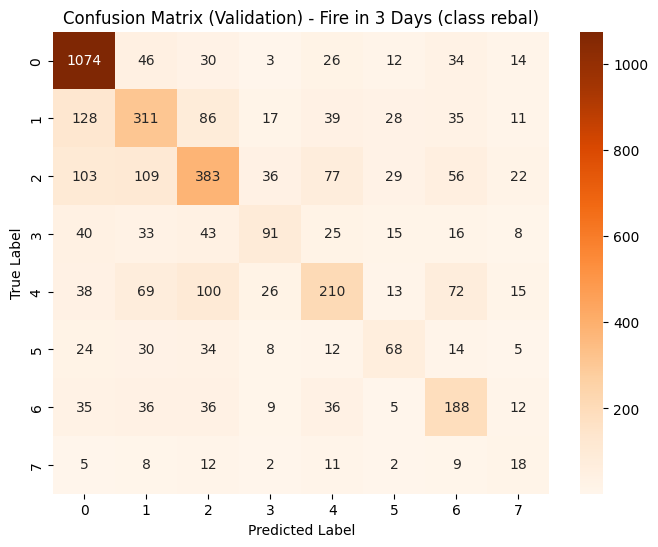

In [ ]:
# Call train function for 3 days -- run model
xgb_3 = run_xgboost_model_class_weights(X_train_3, y_train_3_flat, X_val_3, y_val_3_flat, X_test_3, y_test_3_flat,
                  n_estimators=100, max_depth=4, learning_rate=0.1, label_days=3, sample_weight=sample_weight)

Observation -Slight improvement in Training Accuracy, Validation F1 after weighting classes. Next we'll run SMOTE to try to improve balancing

In [ ]:
#Fire in 7 days -- focus on fire in 3 days to see if we can improve class balance first
#run_xgboost_model_class_weights(X_train_7, y_train_7, X_val_7, y_val_7, X_test_7, y_test_7,
                  #n_estimators=100, max_depth=4, learning_rate=0.1, label_days=3, sample_weight=sample_weight)

In [ ]:
#Fire in 14 days -- focus on fire in 3 days to see if we can improve class balance first
#xgb_14 = run_xgboost_model_class_weights(X_train_14, y_train_14, X_val_14, y_val_14, X_test_14, y_test_14,
                  #n_estimators=100, max_depth=4, learning_rate=0.1, label_days=14, sample_weight=sample_weight)


## Try SMOTE to improve rebalancing classes for 3 day

In [ ]:
#smote balances by creating synthetic data

!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

In [ ]:
#Apply SMOTE to training only!!!!!!
X_train_3, y_train_3_flat
X_val_3, y_val_3_flat
X_test_3, y_test_3_flat

(      T2M_0401  T2M_MAX_0401  T2M_MIN_0401  QV2M_0401  RH2M_0401  \
 0         0.00          0.00          0.00       0.00       0.00   
 1         0.00          0.00          0.00       0.00       0.00   
 2         0.00          0.00          0.00       0.00       0.00   
 3         0.00          0.00          0.00       0.00       0.00   
 4         0.00          0.00          0.00       0.00       0.00   
 ...        ...           ...           ...        ...        ...   
 4137      0.00          0.00          0.00       0.00       0.00   
 4138      5.49         12.68          1.96       4.56      71.83   
 4139      5.77         11.46          1.31       4.50      70.61   
 4140      1.89          7.15         -1.18       3.90      82.26   
 4141      1.43          7.25         -1.49       3.63      79.36   
 
       PRECTOTCORR_0401  WS10M_0401  WS10M_MAX_0401  WS10M_MIN_0401  \
 0                 0.00        0.00            0.00            0.00   
 1                 0.00     

In [ ]:
#Check original class balance
print("Before SMOTE:", Counter(y_train_3_flat))

Before SMOTE: Counter({np.int64(0): 5196, np.int64(2): 2133, np.int64(1): 1982, np.int64(4): 1108, np.int64(6): 890, np.int64(3): 566, np.int64(5): 337, np.int64(7): 214})


In [ ]:
#Apply SMOTE
smote = SMOTE(random_state=42)
X_train_3_sm, y_train_3_sm = smote.fit_resample(X_train_3, y_train_3_flat)

#Check new class balance
print("After SMOTE:", Counter(y_train_3_sm))

After SMOTE: Counter({np.int64(0): 5196, np.int64(1): 5196, np.int64(2): 5196, np.int64(3): 5196, np.int64(4): 5196, np.int64(5): 5196, np.int64(6): 5196, np.int64(7): 5196})


XGBoost Model for Fire in 3 Days WeightedClasses
Training Accuracy: 69.45 %
Validation Accuracy: 57.53 %
Test Accuracy: 53.38 %

 Training Metrics:
Precision : 69.48 %
Recall    : 69.45 %
F1 Score  : 69.22 %
R² Score  : 0.4843

 Validation Metrics:
Precision : 55.86 %
Recall    : 57.53 %
F1 Score  : 56.12 %
R² Score  : 0.1318

 Test Metrics:
Precision : 52.06 %
Recall    : 53.38 %
F1 Score  : 52.41 %
R² Score  : -0.0172


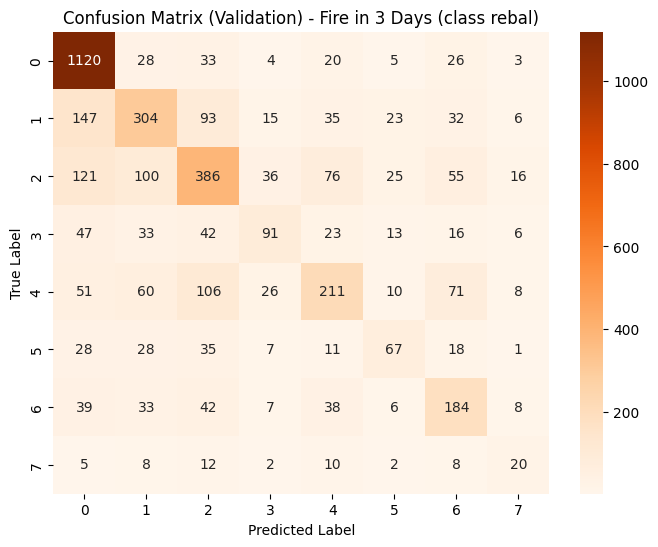

In [ ]:
xgb_3 = run_xgboost_model_class_weights(X_train_3_sm, y_train_3_sm, X_val_3, y_val_3, X_test_3, y_test_3,
                  n_estimators=100, max_depth=4, learning_rate=0.1, label_days=3)

## Findings: slight decrease in perf compared to rebal with weights. Next Step, Last attempt to rebal. This time using ADASYN. the balance is fabricated so model may not generalize welll

In [ ]:
#training only

from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)

X_train_3_adasyn, y_train_3_adasyn = adasyn.fit_resample(X_train_3, y_train_3_flat)


XGBoost Model for Fire in 3 Days WeightedClasses
Training Accuracy: 69.45 %
Validation Accuracy: 57.63 %
Test Accuracy: 53.09 %

 Training Metrics:
Precision : 69.24 %
Recall    : 69.45 %
F1 Score  : 69.14 %
R² Score  : 0.4957

 Validation Metrics:
Precision : 55.92 %
Recall    : 57.63 %
F1 Score  : 56.24 %
R² Score  : 0.1365

 Test Metrics:
Precision : 51.72 %
Recall    : 53.09 %
F1 Score  : 52.11 %
R² Score  : -0.0185


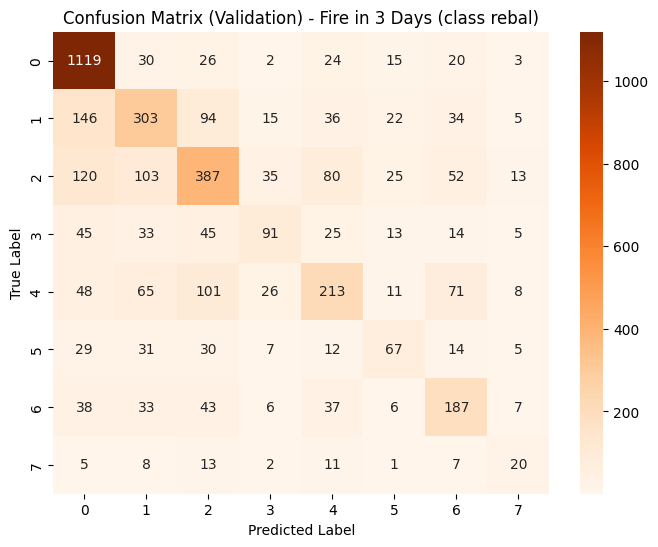

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=20,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
run_xgboost_model_class_weights(X_train_3_adasyn, y_train_3_adasyn, X_val_3, y_val_3, X_test_3, y_test_3, n_estimators=100, max_depth=4,learning_rate=0.1, label_days=3)


# Observations: ADASYN -- Perf moving in the wrong direction. worse than the other 2 options.

## Try RandomSearchCV for tuning

In [ ]:
#Testing parameter variations
param_dict = {
    'learning_rate':[0.005,0.01, 0.015],
    'n_estimators': [250, 300, 350],
    'max_depth':[2,3,4],
    'subsample':[0.8, 0.9, 1.0],
    'colsample_bytree':[0.7, 0.8,0.9,1.0],
    'min_child_weight':[0.9, 1]
}
random_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metrics='mlogloss'),
    param_distributions=param_dict, n_iter=10, n_jobs=-1, scoring='accuracy', cv=3, verbose=4, random_state=42
)

#fit the randomi search to training
random_search.fit(X_train_3, y_train_3_flat, sample_weight=sample_weight)

print("Your Best Parameters are: ", random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Your Best Parameters are:  {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 0.9, 'max_depth': 2, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [ ]:
randsearch_results = []
for i in range(len(random_search.cv_results_['params'])):
    row = random_search.cv_results_['params'][i].copy()
    row['mean_score'] = round(random_search.cv_results_['mean_test_score'][i], 4)
    randsearch_results.append(row)

randsearch_results = pd.DataFrame(randsearch_results).sort_values(by='mean_score', ascending=False).reset_index(drop=True)

#cumulative results
new_results = pd.DataFrame(random_search.cv_results_).sort_values(by='mean_test_score', ascending=False).reset_index(drop=True)

#Append to cumulative resutls
if 'random_search_sofar' not in globals():
    random_search_sofar = new_results
else:
    random_search_sofar = pd.concat([random_search_sofar, new_results], ignore_index=True)
random_search_sofar.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_colsample_bytree,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,201.396645,8.151188,0.750585,0.165646,0.8,250,0.9,7,0.010,1.0,"{'subsample': 0.8, 'n_estimators': 250, 'min_c...",0.550942,0.602125,0.126026,0.426364,0.213397,4
1,70.881902,0.899443,0.406421,0.172886,0.8,200,0.9,5,0.050,1.0,"{'subsample': 0.8, 'n_estimators': 200, 'min_c...",0.506277,0.514969,0.120473,0.380573,0.183953,8
2,51.522394,1.987882,0.501900,0.168119,1.0,250,5.0,5,0.100,0.7,"{'subsample': 1.0, 'n_estimators': 250, 'min_c...",0.510864,0.463544,0.104056,0.359488,0.181648,10
3,167.610222,3.870336,1.162903,0.186016,0.9,300,5.0,7,0.010,0.8,"{'subsample': 0.9, 'n_estimators': 300, 'min_c...",0.543457,0.581845,0.131820,0.419041,0.203699,6
4,157.611534,5.849715,0.565069,0.117070,1.0,150,3.0,9,0.005,0.8,"{'subsample': 1.0, 'n_estimators': 150, 'min_c...",0.555529,0.600435,0.119025,0.424996,0.217130,5


In [ ]:
best_model = random_search.best_estimator_

XGBoost Model for Fire in 3 Days WeightedClasses
Training Accuracy: 63.92 %
Validation Accuracy: 56.23 %
Test Accuracy: 52.41 %

 Training Metrics:
Precision : 65.01 %
Recall    : 63.92 %
F1 Score  : 64.03 %
R² Score  : -0.0184

 Validation Metrics:
Precision : 56.18 %
Recall    : 56.23 %
F1 Score  : 55.64 %
R² Score  : -0.0464

 Test Metrics:
Precision : 53.02 %
Recall    : 52.41 %
F1 Score  : 52.35 %
R² Score  : -0.2224


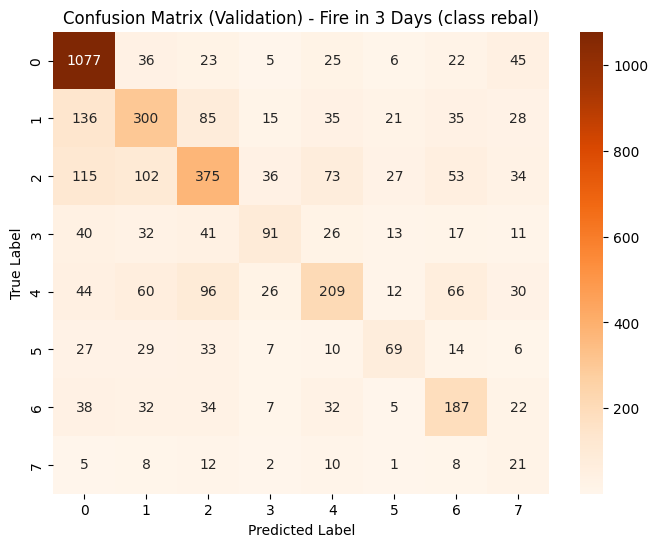

()

In [ ]:
#Random Search eval on train and val only during tuning
evaluate_model(best_model, X_train_3, y_train_3_flat, X_val_3, y_val_3_flat,X_test_3, y_test_3_flat, label_days=3)

Observations: Tuned model has better bal performance and generalization. The initial unbal model was better in terms of accuracy - but that was because it was unbalanced. So better accuracy at the cost of minority classes

In [ ]:
# 7 days -- Focusing on 3 days for now
#random_search_7 = RandomizedSearchCV(
#     estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metrics='mlogloss'),
#     param_distributions=param_dict, n_iter=10, n_jobs=-1, scoring='accuracy', cv=3, verbose=4, random_state=42
# )

# #fit the randomi search to training
# random_search_7.fit(X_train_7, y_train_7_flat, sample_weight=sample_weight)

# print("Your Best Parameters are: ", random_search_7.best_params_)


In [ ]:
#eval on train and val only during tuning -- focusing on 3 day for now
#evaluate_model(random_search_7.best_estimator_, X_train_7, y_train_7_flat, X_val_7, y_val_7_flat,X_test_7, y_test_7_flat, label_days=7)

# **Try GridSearch

In [ ]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

#gridsearch using unflattened/original data
X = X_train_3
y = y_train_3_flat

#initialize result collection
gridsearch_results = []
combinations_tried =  []


#create MSOTE & XGBoost pipeline
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))])




param_grid = {
    'xgb__n_estimators':[100, 150], #tree count
    'xgb__max_depth': [3,4, 5],    #tree depth
    'xgb__learning_rate':[0.01, 0.1], ##adjustment
    'xgb__subsample': [0.8, 1.0],  #% rows used
    'xgb__colsample_bytree': [0.8, 1.0] #% cols used
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    verbose=1,
    n_jobs=-1
)

In [ ]:
#Fit for grid
grid.fit(X, y)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                       ('xgb',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=None,
                                                      device=None,
                                                      early_stopping_rounds=None,
                                                      enable_categorical=False,
                                                      eval_metric='mlogloss',
                                                      feature_types=None,
                                                      feature_weights=None,
                                                      gamma=None,
                                                      gro...
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'xgb__colsample_bytree': [0.8, 1.0],
                         'xgb__learning_rate': [0.01, 0.1],
                         'xgb__max_depth': [3, 4, 5],
                         'xgb__n_estimators': [100, 150],
                         'xgb__subsample': [0.8, 1.0]},
             scoring='f1_weighted', verbose=1)

In [ ]:
for i in range(len(grid.cv_results_['params'])):
    combo = grid.cv_results_['params'][i]
    f1 = grid.cv_results_['mean_test_score'][i]

    row = combo.copy()
    row['mean_f1_score'] = round(f1, 4)

    gridsearch_results.append(row)
    combinations_tried.append(combo)

#create df's
gridresults_df = pd.DataFrame(gridsearch_results)
gridresults_df = gridresults_df.sort_values(by='mean_f1_score', ascending=False).reset_index(drop=True)

gridresults_df.head()

,xgb__colsample_bytree,xgb__learning_rate,xgb__max_depth,xgb__n_estimators,xgb__subsample,mean_f1_score
0,0.8,0.01,3,100,1.0,0.5099
1,0.8,0.01,3,100,0.8,0.5083
2,0.8,0.01,3,150,1.0,0.5006
3,0.8,0.01,3,150,0.8,0.4970
4,1.0,0.01,3,150,1.0,0.4948
